# **Problem Understanding**

The objective of this project is to analyze historical IPL data
to understand match patterns, team performance, and player statistics.

Using match-level and ball-by-ball datasets, this analysis explores:

* Impact of toss decisions on match outcomes
* Team performance across seasons
* Top-performing batsmen and bowlers
* Run-scoring patterns during different overs
* Venue influence on match results
* Types of dismissals in IPL matches

Exploratory Data Analysis (EDA) and visualization techniques
are used to uncover meaningful insights from IPL data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
matches = pd.read_csv("/content/matches.csv")
deliveries = pd.read_csv("/content/deliveries.csv")

Explanation

matches.csv → match level information

deliveries.csv → ball-by-ball information
matches.csv

Contains match-level information such as:

teams

venue

toss result

match winner

Each row represents one IPL match.

deliveries.csv

Contains ball-by-ball data including:

batsman

bowler

runs wickets

Each row represents one ball in the match.

This dataset allows both match-level and player-level analysis.

In [ ]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


We display the first few rows to understand the structure of the datasets and identify the key columns.

Important columns in matches dataset:

team1

team2

venue

toss_winner

toss_decision

winner

Important columns in deliveries dataset:

batter

bowler

batsman_runs

total_runs



In [ ]:
matches.shape

(1095, 20)

In [ ]:
deliveries.shape

(260920, 17)

The shape function returns:

(number of rows, number of columns)

This helps us understand the size of the dataset.

Example:

matches dataset → ~1095 rows

deliveries dataset → ~30525 rows

Each row in matches represents one IPL match.

Each row in deliveries represents one ball in the match.

# **Data Types Check**

In [ ]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [ ]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

The .info() function helps identify:

column data types

missing values

number of records

Understanding data types is important because analysis requires correct data formats.

**Convert Date Column**

In [ ]:
matches['date'] = pd.to_datetime(matches['date'])

We convert the date column into datetime format to enable time-based analysis such as:

season trends

match timelines

**Check Missing Values**

In [ ]:
matches.isnull().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


Missing values can cause errors in analysis.

This step identifies columns with missing data.

Example columns with missing values:

city

player_of_match

umpire3

In [ ]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batter,0
bowler,0
non_striker,0
batsman_runs,0


we can not drop rows of deliveries null values because you would remove almost the entire dataset, since most balls do not have:

wickets

extras

fielders

So those columns will naturally have nulls.

**Data Cleaning**

**Fill missing values.**

In [ ]:
deliveries['player_dismissed'].fillna("Not Out", inplace=True)

deliveries['dismissal_kind'].fillna("None", inplace=True)

deliveries['fielder'].fillna("None", inplace=True)

/tmp/ipykernel_743/1719694798.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries['player_dismissed'].fillna("Not Out", inplace=True)
/tmp/ipykernel_743/1719694798.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

Most balls do not result in wickets, so null simply means:

No dismissal occurred.

In [ ]:
matches['city'].fillna("Unknown", inplace=True)

/tmp/ipykernel_743/2749084892.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['city'].fillna("Unknown", inplace=True)


We replace missing city values with "Unknown" to maintain data consistency.

This prevents errors during grouping or visualization.

In [ ]:
deliveries['extras_type'].fillna("None", inplace=True)

/tmp/ipykernel_743/1392758415.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries['extras_type'].fillna("None", inplace=True)


**Check Duplicate Records**

In [ ]:
matches.duplicated().sum()

np.int64(0)

In [ ]:
deliveries.duplicated().sum()

np.int64(0)

**Feature Engineering We create new variables that help identify patterns.**

In [ ]:
#Toss Advantage Feature
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']

This feature identifies whether:

toss winner = match winner

It helps analyze whether winning the toss increases match winning chances.

**Basic Statistics**

**Outlier Check**

**Correlation Analysis**

In [ ]:
numeric_cols = deliveries[['total_runs','batsman_runs','extra_runs']]

numeric_cols.corr()

,total_runs,batsman_runs,extra_runs
total_runs,1.000000,0.977934,0.067852
batsman_runs,0.977934,1.000000,-0.142079
extra_runs,0.067852,-0.142079,1.000000


<Axes: >

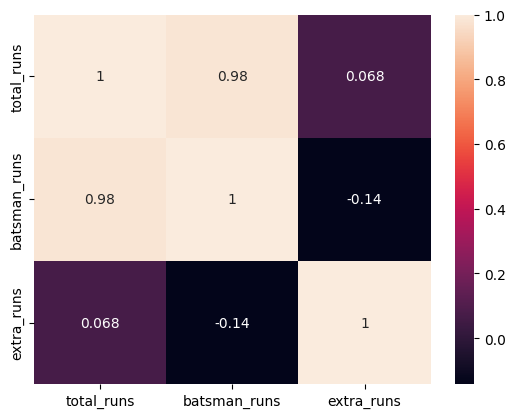

In [ ]:
sns.heatmap(numeric_cols.corr(), annot=True)

Batsman runs strongly correlate with total runs which confirms scoring dependency

<Axes: xlabel='total_runs'>

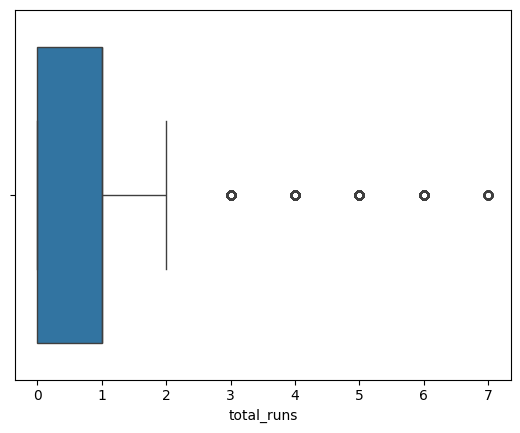

In [ ]:
sns.boxplot(x=deliveries['total_runs'])

Insight:

Some overs contain unusually high scoring events which may represent explosive batting performances.

**Matches Played per Season**

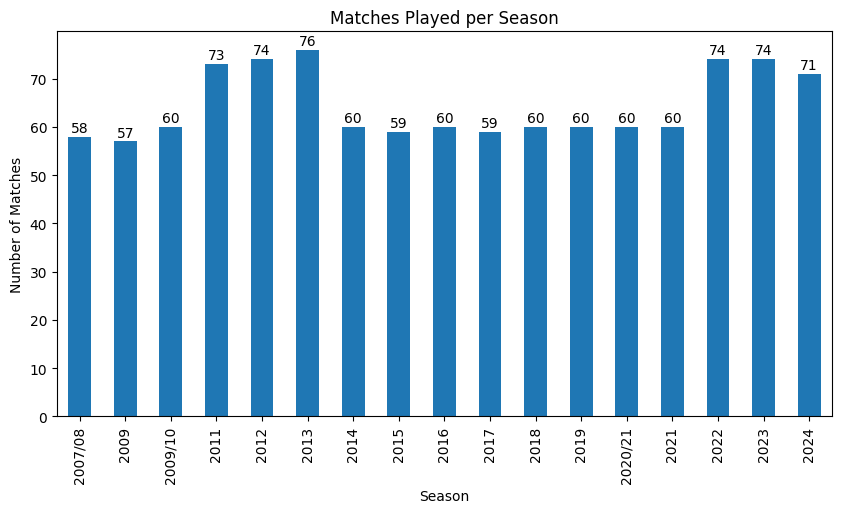

In [ ]:
season_matches = matches['season'].value_counts().sort_index()

plt.figure(figsize=(10,5))
ax = season_matches.plot(kind='bar')

plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

# Add values on top of bars
for i, v in enumerate(season_matches):
    ax.text(i, v + 1, str(v), ha='center')

plt.show()

Insight
Shows how the IPL tournament expanded across seasons.

In [ ]:
matches.describe()

,id,date,result_margin,target_runs,target_overs
count,1.095000e+03,1095,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,2016-06-25 11:39:36.986301184,17.259294,165.684066,19.759341
min,3.359820e+05,2008-04-18 00:00:00,1.000000,43.000000,5.000000
25%,5.483315e+05,2012-04-21 00:00:00,6.000000,146.000000,20.000000
50%,9.809610e+05,2016-05-03 00:00:00,8.000000,166.000000,20.000000
75%,1.254062e+06,2021-04-13 12:00:00,20.000000,187.000000,20.000000
max,1.426312e+06,2024-05-26 00:00:00,146.000000,288.000000,20.000000
std,3.677402e+05,NaN,21.787444,33.427048,1.581108


In [ ]:
deliveries.describe()

,match_id,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
count,2.609200e+05,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000,260920.000000
mean,9.070665e+05,1.483531,9.197677,3.624486,1.265001,0.067806,1.332807,0.049632
std,3.679913e+05,0.502643,5.683484,1.814920,1.639298,0.343265,1.626416,0.217184
min,3.359820e+05,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483340e+05,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,9.809670e+05,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000
75%,1.254066e+06,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000
max,1.426312e+06,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,1.000000


Descriptive statistics summarize numerical columns.

They show:

mean

min

max

standard deviation

This provides an overview of scoring patterns and match metrics.

** Toss Decision Analysis**

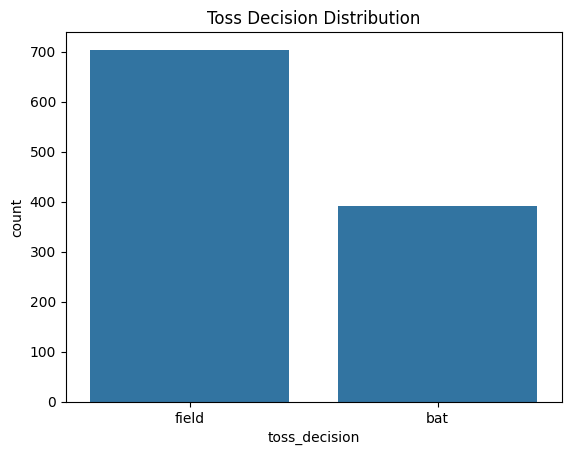

In [ ]:
sns.countplot(x='toss_decision', data=matches)

plt.title("Toss Decision Distribution")
plt.show()

Insight :-
Teams often prefer fielding first.

**Toss Advantage Analysis**

In [ ]:
toss_advantage = matches['toss_win_match_win'].value_counts()
toss_advantage

,count
toss_win_match_win,
True,554
False,541


**Toss Win Indicator**

In [ ]:
matches['toss_win_match_win'] = (matches['toss_winner'] == matches['winner'])

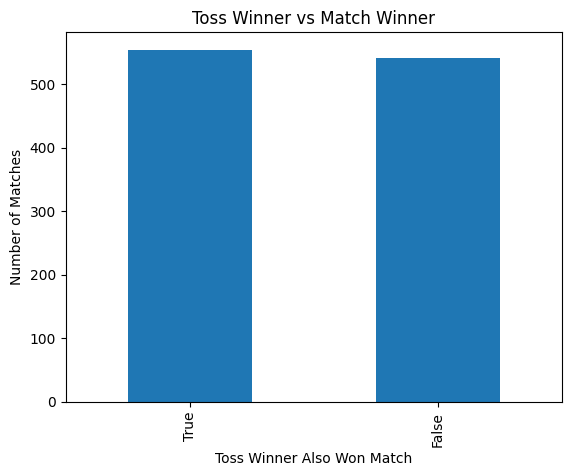

In [ ]:
toss_advantage.plot(kind='bar')
plt.title("Toss Winner vs Match Winner")
plt.xlabel("Toss Winner Also Won Match")
plt.ylabel("Number of Matches")
plt.show()

True Toss winner also won match False Toss winner lost match

Insight

This analysis evaluates whether winning the toss influences match outcomes.

**Toss Decision Strategy**

In [ ]:
matches['toss_decision'].value_counts()

,count
toss_decision,
field,704
bat,391


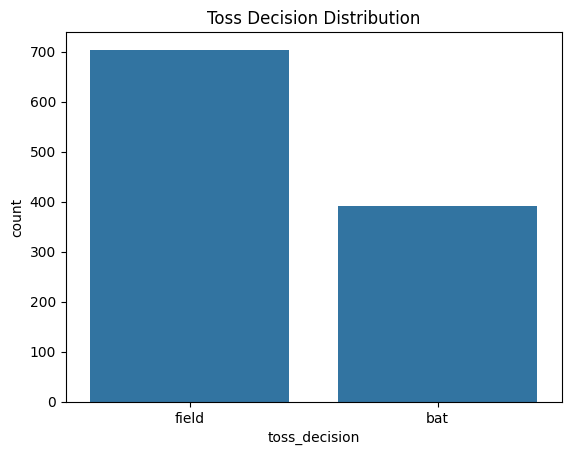

In [ ]:
sns.countplot(x='toss_decision', data=matches)
plt.title("Toss Decision Distribution")
plt.show()

**Most Successful Teams**

In [ ]:
team_wins = matches['winner'].value_counts()
team_wins.head(10)

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Sunrisers Hyderabad,88
Kings XI Punjab,88
Delhi Daredevils,67
Delhi Capitals,48


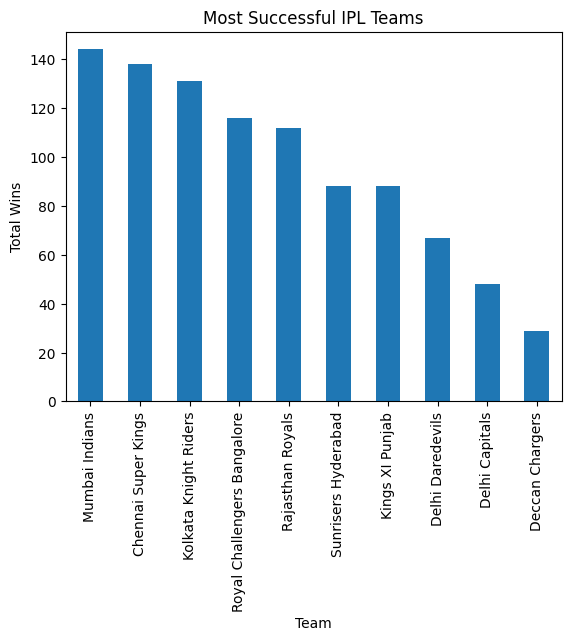

In [ ]:
team_wins.head(10).plot(kind='bar')
plt.title("Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Total Wins")
plt.show()

Insight

Certain teams dominate IPL due to strong team composition and consistency.



** Win Percentage by Team**

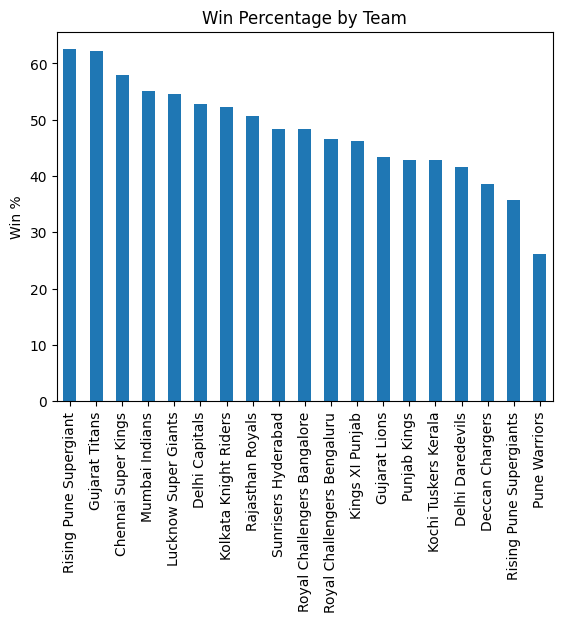

In [ ]:
total_matches = matches['team1'].value_counts() + matches['team2'].value_counts()

wins = matches['winner'].value_counts()

win_percentage = (wins / total_matches) * 100

win_percentage.sort_values(ascending=False).plot(kind='bar')

plt.title("Win Percentage by Team")
plt.ylabel("Win %")
plt.show()

Win percentage provides a fair comparison of team performance.

**Venue Analysis**

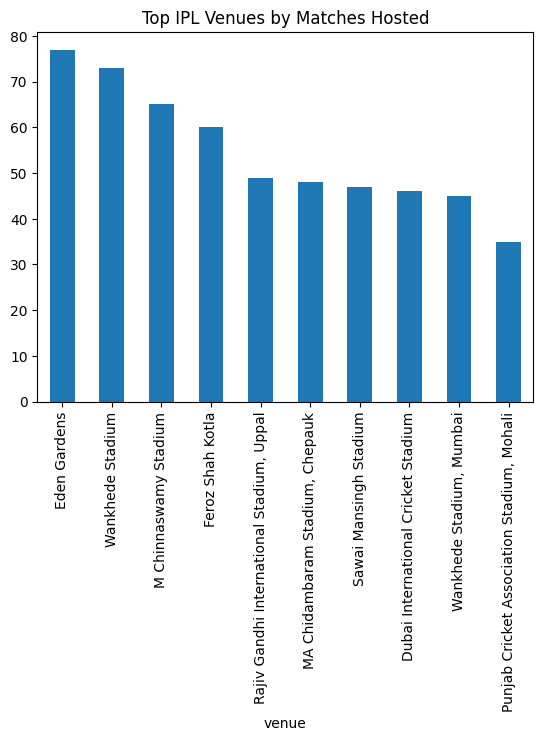

In [ ]:
matches['venue'].value_counts().head(10).plot(kind='bar')

plt.title("Top IPL Venues by Matches Hosted")
plt.show()

Insight
Some stadiums host a large number of IPL matches.

**Runs Per Over Trend**

In [ ]:
runs_per_over = deliveries.groupby('over')['total_runs'].mean()
runs_per_over

,total_runs
over,
0,0.981663
1,1.173528
2,1.316099
3,1.356538
4,1.369100
5,1.373055
6,1.103107
7,1.189948
8,1.242087


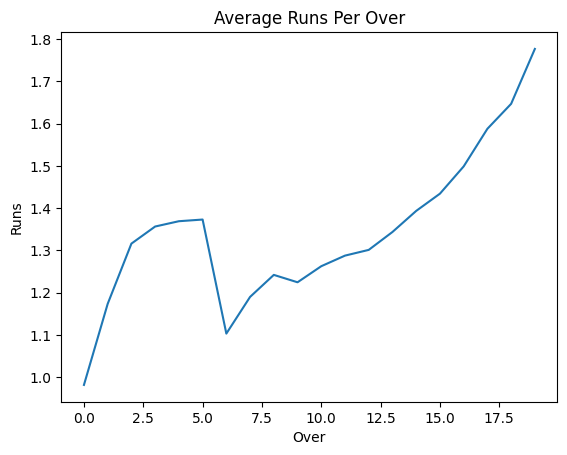

In [ ]:
runs_per_over.plot()
plt.title("Average Runs Per Over")
plt.xlabel("Over")
plt.ylabel("Runs")
plt.show()

Insight

Run rates increase significantly in death overs (16–20) due to aggressive batting.

**Top Run Scorers**

In [ ]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
top_batsmen

,batsman_runs
batter,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
MS Dhoni,5243
AB de Villiers,5181
CH Gayle,4997
RV Uthappa,4954


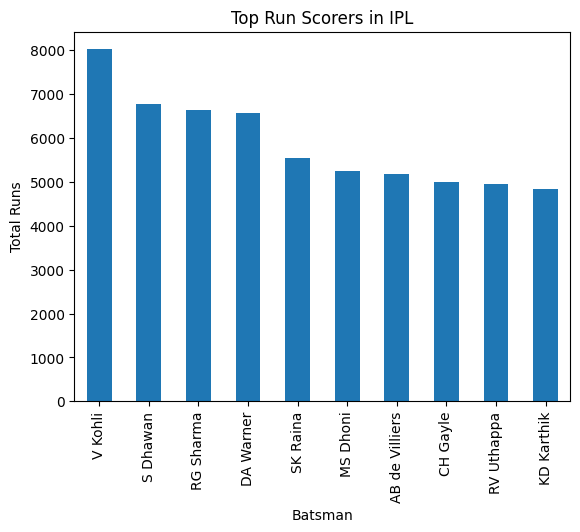

In [ ]:
top_batsmen.plot(kind='bar')
plt.title("Top Run Scorers in IPL")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.show()

Insight

Consistent high-performing batsmen significantly impact match results.

**Top Wicket Takers**

In [ ]:
wickets = deliveries[deliveries['is_wicket'] == 1]

top_bowlers = wickets.groupby('bowler').size().sort_values(ascending=False).head(10)
top_bowlers

,0
bowler,
YS Chahal,213
DJ Bravo,207
PP Chawla,201
SP Narine,200
R Ashwin,198
B Kumar,195
SL Malinga,188
A Mishra,183
JJ Bumrah,182


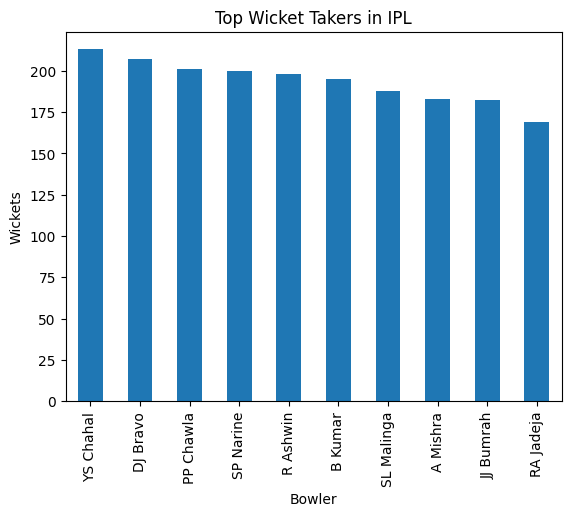

In [ ]:
top_bowlers.plot(kind='bar')
plt.title("Top Wicket Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.show()

Insight

Strike bowlers are critical in controlling match momentum.

**Venue Advantage Analysis**

In [ ]:
venue_team = pd.crosstab(matches['venue'], matches['winner'])

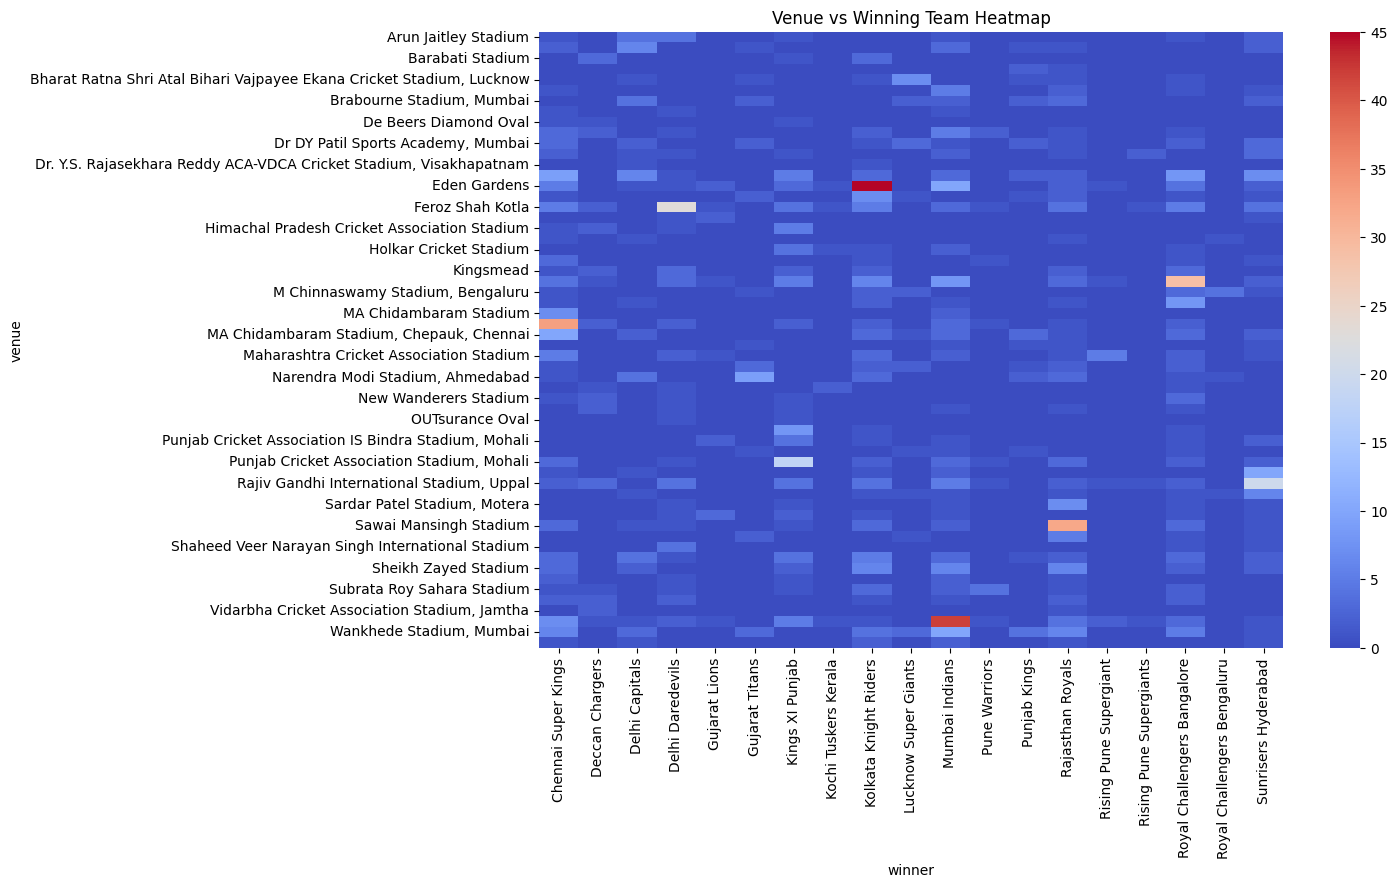

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(venue_team, cmap="coolwarm")
plt.title("Venue vs Winning Team Heatmap")
plt.show()

**Powerplay Scoring**

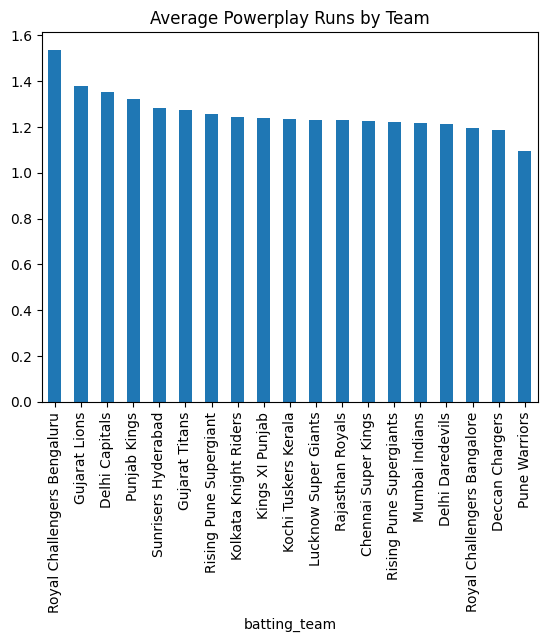

In [ ]:
powerplay = deliveries[deliveries['over'] <= 6]

powerplay.groupby('batting_team')['total_runs'].mean()\
.sort_values(ascending=False).plot(kind='bar')

plt.title("Average Powerplay Runs by Team")
plt.show()

Insight
Shows teams that perform strongly in the powerplay phase.

**Death Over Scoring**

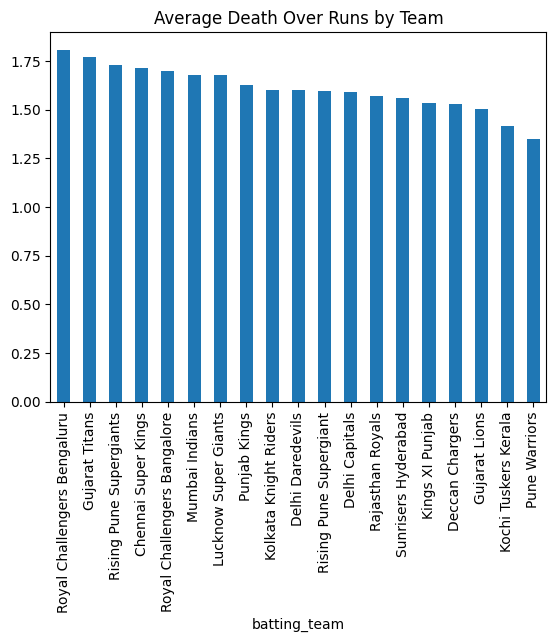

In [ ]:
death = deliveries[deliveries['over'] >= 16]

death.groupby('batting_team')['total_runs'].mean()\
.sort_values(ascending=False).plot(kind='bar')

plt.title("Average Death Over Runs by Team")
plt.show()

Insight
Teams accelerate scoring during final overs.

**Correlation Heatmap**

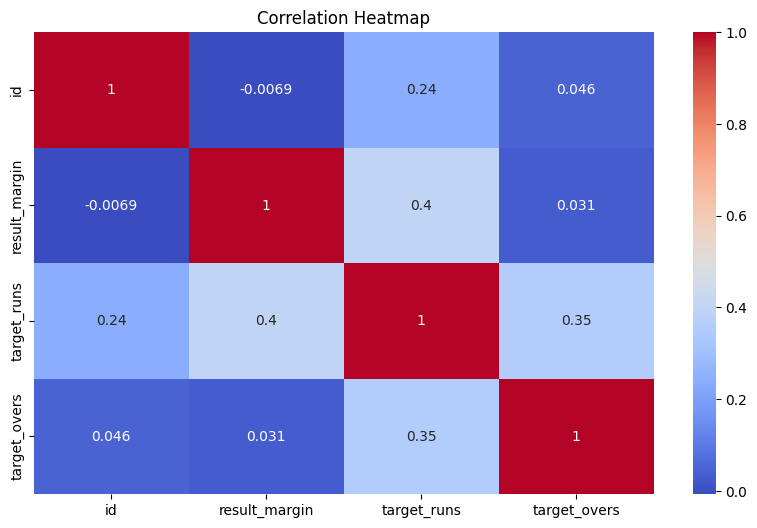

In [ ]:
numeric_cols = matches.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Purpose
Shows relationships between numeric variables.

 Key Insights
Example:

Winning the toss provides a slight advantage but does not guarantee victory.

Certain teams dominate IPL historically with higher win counts.

Run scoring increases significantly during death overs.

A few batsmen dominate total run scoring.

Some bowlers consistently lead wicket statistics.

Teams show different scoring patterns during powerplay and death overs.


Conclusion
Example:

This analysis explored IPL match and ball-by-ball datasets
to understand team performance, player contributions,
and scoring patterns.

Through exploratory data analysis and visualization,
key insights were identified regarding toss impact,
team dominance, player performance, and scoring trends.

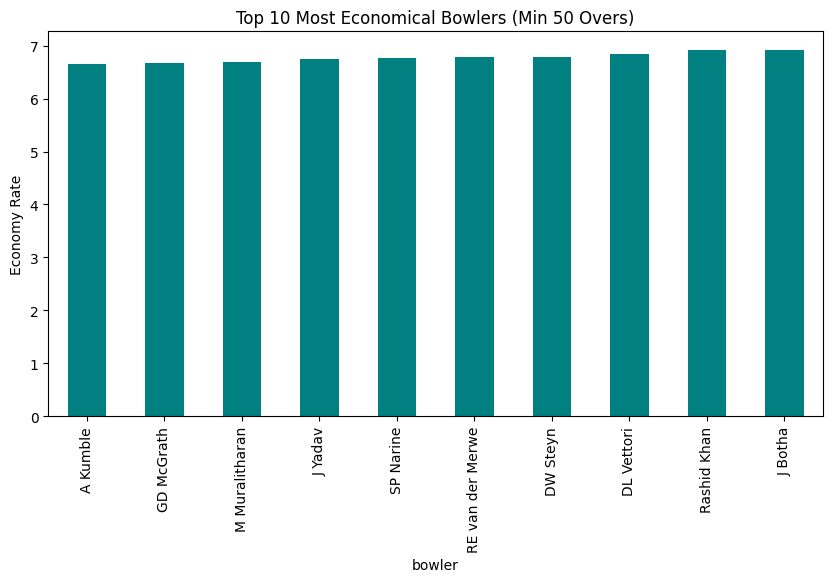

In [ ]:
# Grouping by bowler to get total runs conceded and balls bowled
bowler_stats = deliveries.groupby('bowler').agg({'total_runs': 'sum', 'ball': 'count'})

# Calculate Economy (Runs per 6 balls)
bowler_stats['economy'] = (bowler_stats['total_runs'] / bowler_stats['ball']) * 6

# Filter for bowlers who have bowled at least 300 balls (50 overs) for accuracy
efficient_bowlers = bowler_stats[bowler_stats['ball'] > 300].sort_values(by='economy').head(10)

plt.figure(figsize=(10,5))
efficient_bowlers['economy'].plot(kind='bar', color='teal')
plt.title("Top 10 Most Economical Bowlers (Min 50 Overs)")
plt.ylabel("Economy Rate")
plt.show()

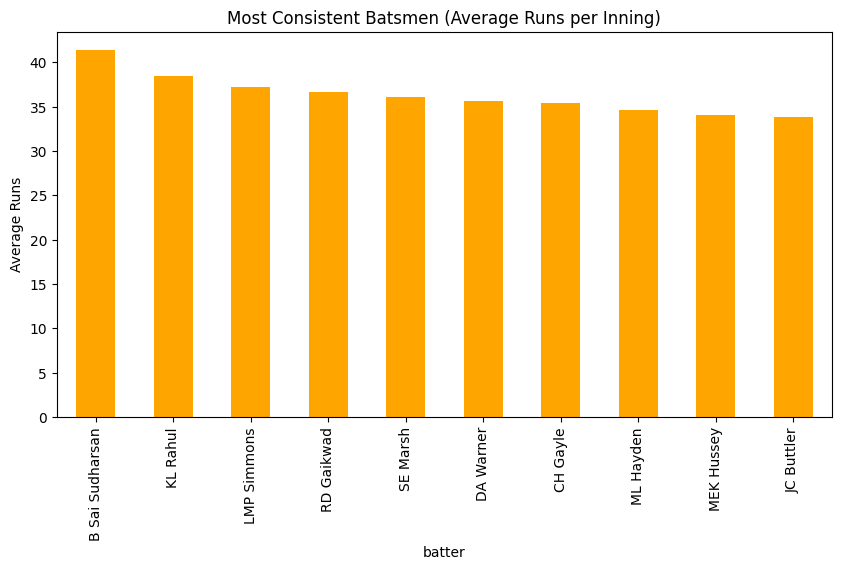

In [ ]:
# Calculate total runs and number of matches played by each batter
batter_runs = deliveries.groupby('batter')['batsman_runs'].sum()
batter_innings = deliveries.groupby('batter')['match_id'].nunique()

# Calculate Average
batter_avg = (batter_runs / batter_innings).sort_values(ascending=False)

# Filter for top scorers (e.g., more than 1000 total runs) to see the most consistent ones
consistent_batsmen = batter_avg[batter_runs > 1000].head(10)

plt.figure(figsize=(10,5))
consistent_batsmen.plot(kind='bar', color='orange')
plt.title("Most Consistent Batsmen (Average Runs per Inning)")
plt.ylabel("Average Runs")
plt.show()

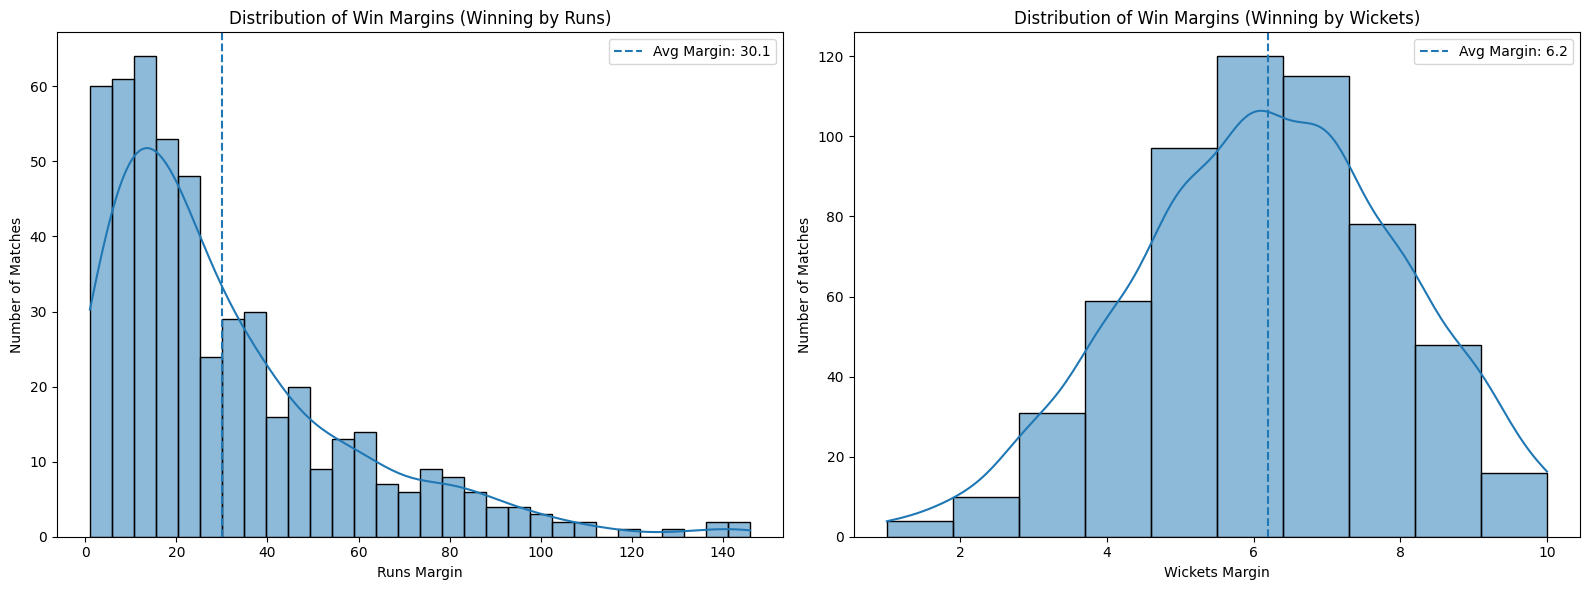

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 2 subplots
fig, ax = plt.subplots(1, 2, figsize=(16,6))

# Wins by Runs (Defending)
runs_wins = matches[matches['result'] == 'runs']['result_margin']

sns.histplot(runs_wins, bins=30, kde=True, ax=ax[0])

ax[0].set_title("Distribution of Win Margins (Winning by Runs)")
ax[0].set_xlabel("Runs Margin")
ax[0].set_ylabel("Number of Matches")

ax[0].axvline(runs_wins.mean(), linestyle='--', label=f'Avg Margin: {runs_wins.mean():.1f}')
ax[0].legend()

# Wins by Wickets (Chasing)
wickets_wins = matches[matches['result'] == 'wickets']['result_margin']

sns.histplot(wickets_wins, bins=10, kde=True, ax=ax[1])

ax[1].set_title("Distribution of Win Margins (Winning by Wickets)")
ax[1].set_xlabel("Wickets Margin")
ax[1].set_ylabel("Number of Matches")

ax[1].axvline(wickets_wins.mean(), linestyle='--', label=f'Avg Margin: {wickets_wins.mean():.1f}')
ax[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_743/3704668923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_mom.index, y=top_mom.values, palette="magma")


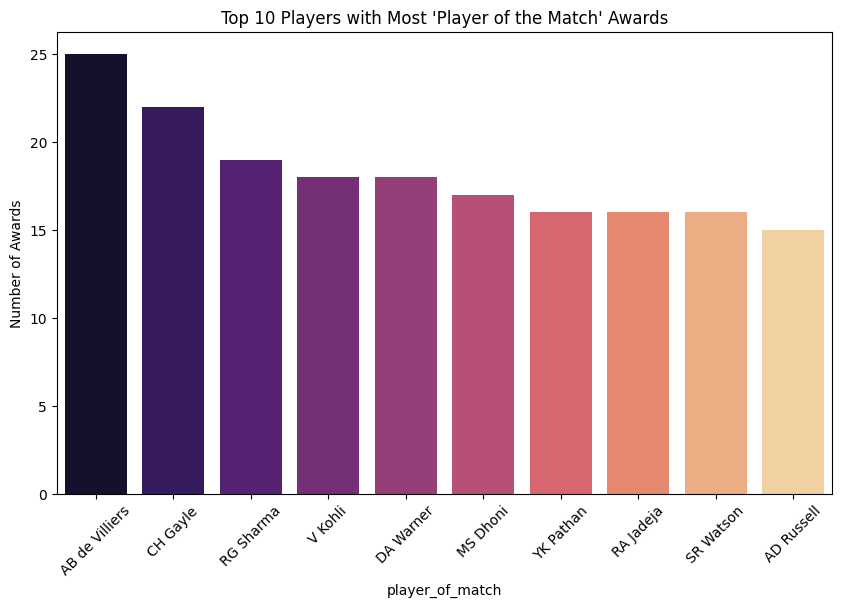

In [ ]:
# Top 10 Match Winners
plt.figure(figsize=(10,6))
top_mom = matches['player_of_match'].value_counts().head(10)
sns.barplot(x=top_mom.index, y=top_mom.values, palette="magma")
plt.title("Top 10 Players with Most 'Player of the Match' Awards")
plt.ylabel("Number of Awards")
plt.xticks(rotation=45)
plt.show()

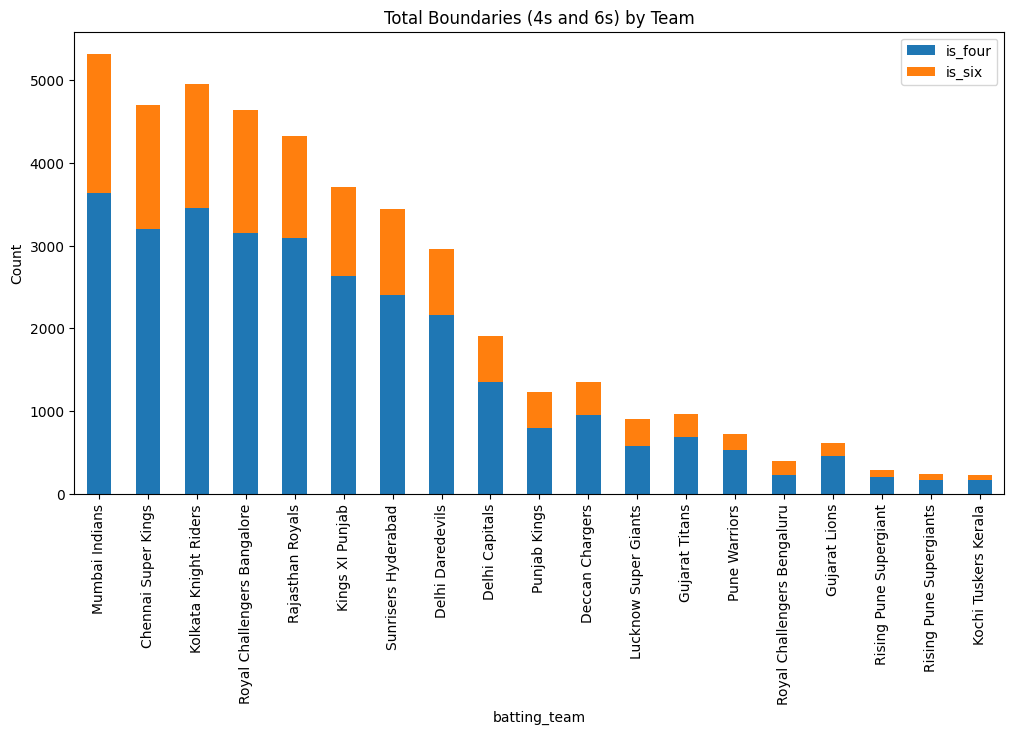

In [ ]:
# Identifying 4s and 6s
deliveries['is_four'] = deliveries['batsman_runs'] == 4
deliveries['is_six'] = deliveries['batsman_runs'] == 6

# Aggregating by team
boundary_stats = deliveries.groupby('batting_team').agg({'is_four': 'sum', 'is_six': 'sum'})

# Plotting
boundary_stats.sort_values(by='is_six', ascending=False).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Total Boundaries (4s and 6s) by Team")
plt.ylabel("Count")
plt.show()

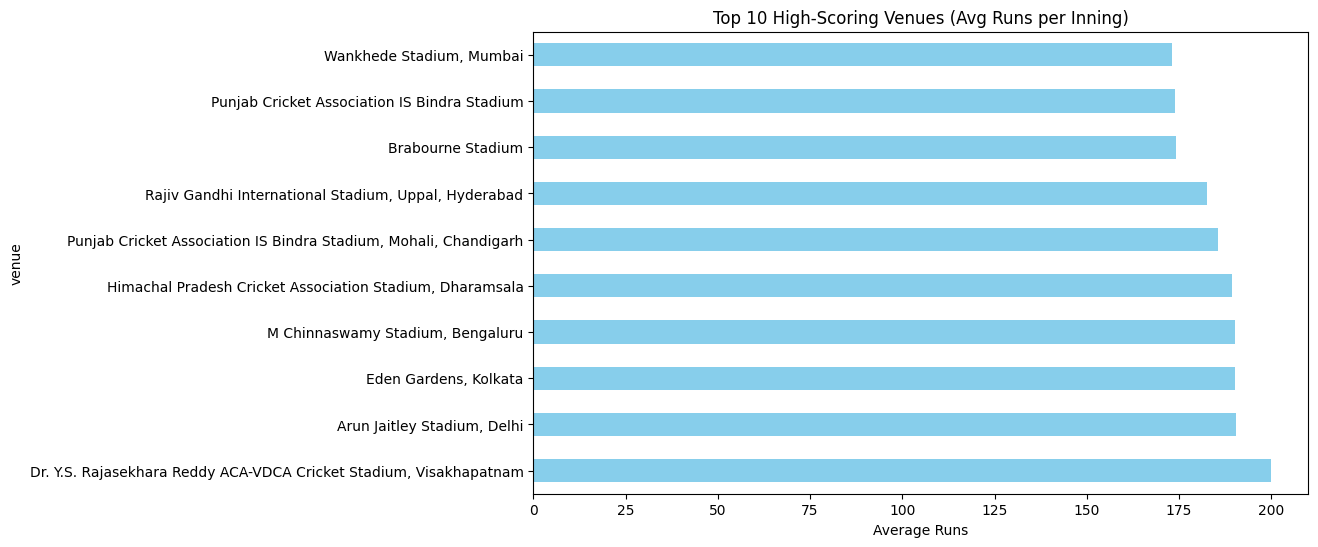

In [ ]:
# Calculate average total score per match at each venue
venue_scores = deliveries.groupby(['match_id', 'batting_team']).agg({'total_runs': 'sum'}).reset_index()
venue_scores = pd.merge(venue_scores, matches[['id', 'venue']], left_on='match_id', right_on='id')

avg_venue_score = venue_scores.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
avg_venue_score.plot(kind='barh', color='skyblue')
plt.title("Top 10 High-Scoring Venues (Avg Runs per Inning)")
plt.xlabel("Average Runs")
plt.show()

In [ ]:
# Calculate Standard Deviation and Mean for players with > 10 innings
player_runs_per_match = deliveries.groupby(['batter', 'match_id'])['batsman_runs'].sum().reset_index()
consistency = player_runs_per_match.groupby('batter')['batsman_runs'].agg(['std', 'mean', 'count'])

# CV = (Std Dev / Mean) * 100. Lower is more consistent.
consistency['consistency_score'] = (consistency['std'] / consistency['mean']) * 100

# Filter for experienced players
reliable_players = consistency[consistency['count'] > 20].sort_values('consistency_score').head(10)

print("Most Consistent Players (Lowest variance in scores):")
print(reliable_players[['mean', 'consistency_score']])

Most Consistent Players (Lowest variance in scores):
                      mean  consistency_score
batter                                       
B Sai Sudharsan  41.360000          63.005405
Tilak Varma      30.421053          64.427577
JM Sharma        20.277778          66.169525
A Ashish Reddy   12.173913          72.911474
AK Markram       23.690476          73.618083
R Dravid         26.512195          73.625332
Abdul Samad      14.846154          74.439531
R Sathish        11.250000          74.887642
DB Das           13.818182          75.625334
RA Jadeja        16.438889          75.643384


In [ ]:
# Merge deliveries with match results
deliveries_with_result = pd.merge(deliveries, matches[['id', 'winner']], left_on='match_id', right_on='id')

# Calculate runs in winning matches vs total runs
player_win_runs = deliveries_with_result[deliveries_with_result['batting_team'] == deliveries_with_result['winner']]
win_runs_total = player_win_runs.groupby('batter')['batsman_runs'].sum()
total_runs_total = deliveries.groupby('batter')['batsman_runs'].sum()

# Clutch % = Percentage of a player's runs that contributed to a win
clutch_index = (win_runs_total / total_runs_total * 100).sort_values(ascending=False)

# Filter for top scorers (min 1000 runs)
print("Highest Contribution to Team Wins (Min 1000 runs):")
print(clutch_index[total_runs_total > 1000].head(10))

Highest Contribution to Team Wins (Min 1000 runs):
batter
MEK Hussey      82.397572
LMP Simmons     74.235403
Shubman Gill    70.087065
TM Dilshan      68.950564
RD Gaikwad      67.815126
G Gambhir       67.322741
V Sehwag        66.239003
PP Shaw         66.173362
ML Hayden       65.943993
MP Stoinis      65.058950
Name: batsman_runs, dtype: float64


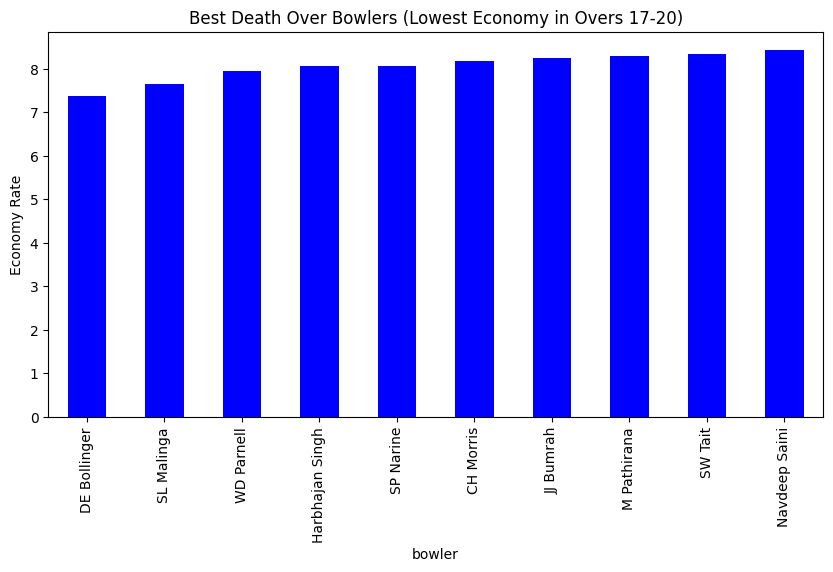

In [ ]:
# Filter for Death Overs only
death_overs = deliveries[deliveries['over'] >= 17]

# Calculate Economy in the Death
death_bowler = death_overs.groupby('bowler').agg({'total_runs': 'sum', 'ball': 'count'})
death_bowler['economy'] = (death_bowler['total_runs'] / death_bowler['ball']) * 6

# Minimum 100 balls in the death to be relevant
specialists = death_bowler[death_bowler['ball'] > 100].sort_values('economy').head(10)

plt.figure(figsize=(10, 5))
specialists['economy'].plot(kind='bar', color='blue')
plt.title("Best Death Over Bowlers (Lowest Economy in Overs 17-20)")
plt.ylabel("Economy Rate")
plt.show()

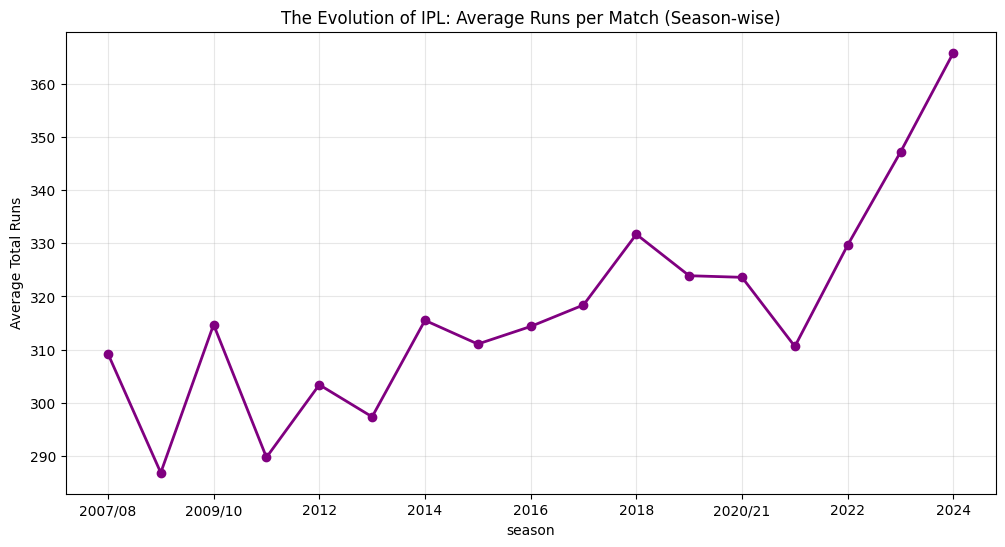

In [ ]:
# Calculate average runs per match for each season
season_scoring = deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
season_avg = season_scoring.groupby('season')['total_runs'].sum() / matches.groupby('season')['id'].count()

plt.figure(figsize=(12, 6))
season_avg.plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title("The Evolution of IPL: Average Runs per Match (Season-wise)")
plt.ylabel("Average Total Runs")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Count wins by 'runs' (defending) and 'wickets' (chasing) per venue
venue_trends = matches.groupby(['venue', 'result']).size().unstack().fillna(0)
venue_trends['Chase_Win_Percentage'] = (venue_trends['wickets'] / (venue_trends['wickets'] + venue_trends['runs'])) * 100

# Filter for major venues (at least 20 matches)
major_venues = venue_trends[(venue_trends['wickets'] + venue_trends['runs']) > 20]
major_venues = major_venues.sort_values('Chase_Win_Percentage', ascending=False)

print("Top Chasing Venues (Advantage to Field First):")
print(major_venues[['Chase_Win_Percentage']].head(5))

Top Chasing Venues (Advantage to Field First):
result                                   Chase_Win_Percentage
venue                                                        
Sawai Mansingh Stadium                              68.085106
Sharjah Cricket Stadium                             64.285714
Maharashtra Cricket Association Stadium             63.636364
Narendra Modi Stadium, Ahmedabad                    62.500000
Wankhede Stadium, Mumbai                            60.000000


In [ ]:
# 1. Calculate runs per match, grouping by both Batter and Team
player_runs_per_match = deliveries.groupby(['batter', 'batting_team', 'match_id'])['batsman_runs'].sum().reset_index()

# 2. Calculate Std, Mean, and Innings Count for each Batter-Team combination
consistency = player_runs_per_match.groupby(['batter', 'batting_team'])['batsman_runs'].agg(['std', 'mean', 'count'])

# 3. CV = (Std Dev / Mean) * 100. Lower is more consistent (less variance).
consistency['consistency_score'] = (consistency['std'] / consistency['mean']) * 100

# 4. Filter for experienced players (e.g., more than 20 innings for that specific team)
# This removes 'one-hit wonders' and shows truly reliable players
reliable_players = consistency[consistency['count'] > 20].sort_values('consistency_score').head(10)

print("Most Consistent Players per Team (Lowest variance in scores):")
# Reset index to make 'batter' and 'batting_team' regular columns for better printing
print(reliable_players[['mean', 'consistency_score']].reset_index())

Most Consistent Players per Team (Lowest variance in scores):
            batter         batting_team       mean  consistency_score
0        SPD Smith        Pune Warriors  24.809524          54.654692
1        RA Jadeja        Gujarat Lions  13.960000          62.396347
2  B Sai Sudharsan       Gujarat Titans  41.360000          63.005405
3      Tilak Varma       Mumbai Indians  30.421053          64.427577
4  Y Venugopal Rao     Delhi Daredevils  22.285714          65.120444
5         R Dravid     Rajasthan Royals  28.355556          65.840930
6        JM Sharma         Punjab Kings  20.277778          66.169525
7        DA Warner  Sunrisers Hyderabad  42.273684          68.236419
8          RR Pant       Delhi Capitals  28.458333          68.419792
9         KL Rahul      Kings XI Punjab  45.904762          68.557362


In [ ]:
# Identify who has dismissed which batter the most
dismissals = deliveries[deliveries['player_dismissed'].notnull()]
matchups = dismissals.groupby(['batter', 'bowler']).size().reset_index(name='dismissals')

# Filter for the most famous "Rivalries" (e.g., Bowler has got Batter out > 4 times)
top_rivalries = matchups.sort_values(by='dismissals', ascending=False).head(10)

print("Top Batter vs Bowler Rivalries (Most Frequent Dismissals):")
print(top_rivalries)

Top Batter vs Bowler Rivalries (Most Frequent Dismissals):
          batter           bowler  dismissals
26199    V Kohli         R Ashwin         153
26208    V Kohli        RA Jadeja         148
19788  RG Sharma        SP Narine         136
5481   DA Warner        SP Narine         127
11655   KL Rahul        JJ Bumrah         126
22427   SK Raina  Harbhajan Singh         125
21179   S Dhawan  Harbhajan Singh         123
19809  RG Sharma         UT Yadav         121
5438   DA Warner         R Ashwin         118
26240    V Kohli        SP Narine         118


In [ ]:
# Calculate total runs from boundaries (4s and 6s)
deliveries['boundary_runs'] = 0
deliveries.loc[deliveries['batsman_runs'] == 4, 'boundary_runs'] = 4
deliveries.loc[deliveries['batsman_runs'] == 6, 'boundary_runs'] = 6

# Aggregating by Team
team_aggression = deliveries.groupby('batting_team').agg({'batsman_runs': 'sum', 'boundary_runs': 'sum'})
team_aggression['boundary_percent'] = (team_aggression['boundary_runs'] / team_aggression['batsman_runs']) * 100

# Sorting by most aggressive teams
print("Aggression Index: Teams that rely most on Boundaries:")
print(team_aggression['boundary_percent'].sort_values(ascending=False))

Aggression Index: Teams that rely most on Boundaries:
batting_team
Royal Challengers Bengaluru    68.339907
Punjab Kings                   64.366291
Mumbai Indians                 61.728333
Kolkata Knight Riders          61.412151
Delhi Capitals                 61.198960
Lucknow Super Giants           60.725886
Royal Challengers Bangalore    60.106116
Gujarat Lions                  59.840138
Rajasthan Royals               59.823426
Gujarat Titans                 59.671062
Kings XI Punjab                59.472338
Chennai Super Kings            59.440921
Delhi Daredevils               58.335505
Sunrisers Hyderabad            57.421946
Deccan Chargers                57.216353
Kochi Tuskers Kerala           56.769056
Rising Pune Supergiant         55.780591
Rising Pune Supergiants        55.657492
Pune Warriors                  54.238411
Name: boundary_percent, dtype: float64
